# Análisis Exploratorio de Datos (EDA)

Antes de la implementación de los algoritmos, se realiza un diagnóstico profundo del conjunto de datos con el objetivo de identificar la estructura de las variables, detectar valores atípicos o faltantes, y comprender los componentes estadísticos principales de la operación comercial. Esta fase es fundamental para validar visual y estadísticamente los supuestos de estacionalidad y tendencia en las ventas antes de su modelado.


In [1]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from src.db_conn import DatabaseConnection
from config.settings import (
    DB_HOST,
    DB_PASSWORD,
    DB_NAME,
    DB_PORT,
    DB_USER,
    SSH_IP,
    SSH_PRIVATE_KEY,
    SSH_USERNAME,
    SSH_PORT,
    DATA_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


## Extracción de datos

Tras mapear con éxito el catálogo global de la base de datos operativa, se identificaron 49 entidades relacionales activas. Con el objetivo de optimizar los recursos de cómputo y focalizar el análisis estadístico en el comportamiento del mercado, el alcance del proyecto se delimita estrictamente a la extracción y procesamiento de dos tablas núcleo:

* customers.

    Tabla maestro que almacena el perfilamiento base de los clientes. De esta entidad se extraerán los atributos críticos para la fase de clasificación y perfilamiento, tales como los identificadores únicos, las fechas de alta operativas y las segmentaciones comerciales nativas necesarias para determinar si un prospecto se consolidará como un cliente de alto valor.

* sale_transactions.

    Historico transaccional que registra los movimientos diarios de venta neta, venta total, utilidad, etc. Esta entidad constituye el núcleo de información para los modelos de series de tiempo, proveyendo los volúmenes, montos de facturación y marcas temporales requeridos por los algoritmos SARIMAX, Prophet y LSTM para proyectar la demanda en las distintas rutas comerciales.

Teniendo en cuenta que el primer paso es el EDA, los datos necesitan estar en un formato legible e interpretable, no pueden pasar en este momento directo a ningún modelo, por eso, se agregó la conexión desde el archivo `core/main.py` a través de la consulta `SELECT * FROM sale_transactions` y `SELECT * FROM customers`, a través del método *query_to_csv* desarrollado dentro de la clase `DatabaseConnection`, para que de ahora en adelante, cada vez que se ejecute el script, se deje envidencia de cual fue el último set de datos utilizado tanto para entrenamiento como para EDA.

In [72]:
#Dado que main, usa una clase definida en src/db_conn.py, podemos reutilizar esos mismos métodos cada que sea necesario
new_conn = DatabaseConnection(
    DB_HOST=DB_HOST,
    DB_NAME=DB_NAME,
    DB_PASSWORD=DB_PASSWORD,
    DB_PORT=DB_PORT,
    DB_USER=DB_USER,
    SSH_PRIVATE_KEY=SSH_PRIVATE_KEY,
    SSH_IP=SSH_IP,
    SSH_USERNAME=SSH_USERNAME,
    SSH_PORT=SSH_PORT
    )

sale_transactions_query = """
SELECT * FROM sale_transactions
"""

customers_query = """
SELECT * FROM customers
"""


new_conn.setup_status()
new_conn.query_to_csv(query=sale_transactions_query, output_file_name=DATA_DIR / 'sales.csv')
new_conn.query_to_csv(query=customers_query, output_file_name=DATA_DIR / 'customers.csv')

DB Host: datall-urvet.cd2aek2kwyme.mx-central-1.rds.amazonaws.com -> as <class 'str'>
DB name: postgres -> as <class 'str'>
Password: *******
DB port: 5432 -> as <class 'int'>
DB username: postgres -> as <class 'str'>
ssh ip: 78.14.2.61 -> as <class 'str'>
ssh username: ubuntu -> as <class 'str'>
ssh private key: /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/datall-aws-server/datall-ec2-keys.pem -> as <class 'str'>
ssh port: 22 -> as <class 'int'>
Server connected
Query: 
SELECT * FROM sale_transactions


Preview

       id    doc_id   sale_date   total_cost    net_price  gross_price  \
0  654255  mx 51841  2025-08-04  5681.140252  7500.000000  7500.000000   
1  654256  mx 51841  2025-08-04   353.420434   469.827600   469.827600   
2  654257  mx 51841  2025-08-04  1240.348891  1646.551700  1646.551700   
3  654258  mx 51841  2025-08-04   649.051367   862.069000   862.069000   
4  654259  mx 51841  2025-08-04   424.642649   556.034500   556.0

True

In [2]:
# una vez definidos los datos y exportados a csv en la carpeta data, podemos llamarlos y convertirlos a df
customers = pd.read_csv(DATA_DIR / 'customers.csv')
sales = pd.read_csv(DATA_DIR / 'sales.csv')

display(customers.head())
display(sales.head())

,code,name,registration_date,credit_limit,credit_days,customer_type_id,opinion_leader
0,10420,leticia govea vazquez,2006-12-29,"10,000.00",15,8,False
1,10531,miguel angel dominguez galvez,2006-12-29,"10,000.00",15,5,False
2,10854,rodolfo gomez ortiz,2006-12-29,"10,000.00",30,5,False
3,10858,maria adela gutierrez salcido,2006-12-29,"60,000.00",30,8,False
4,10860,jose ramon gallegos velasquez,2006-12-29,"10,000.00",30,5,False


,id,doc_id,sale_date,total_cost,net_price,gross_price,profit,quantity,customer_id,product_id,product_class_id,route_id,warehouse_id
0,654255,mx 51841,2025-08-04,"5,681.14","7,500.00","7,500.00","1,818.86",8,20889,NLAM40,nat,96.00,cdmx
1,654256,mx 51841,2025-08-04,353.42,469.83,469.83,116.41,2,20889,NLAM6,nat,96.00,cdmx
2,654257,mx 51841,2025-08-04,"1,240.35","1,646.55","1,646.55",406.20,2,20889,PREM40,dmd,96.00,cdmx
3,654258,mx 51841,2025-08-04,649.05,862.07,862.07,213.02,5,20889,PREM6,dmd,96.00,cdmx
4,654259,mx 51841,2025-08-04,424.64,556.03,556.03,131.39,2,20889,PSC5,tow,96.00,cdmx


In [3]:
print('Conteo de nulos de sales')
print(sales.isna().sum())


print('Conteo de nulos de customers\n')
print(customers.isna().sum())

Conteo de nulos de sales
id                     0
doc_id                 0
sale_date              0
total_cost             0
net_price              0
gross_price            0
profit                 0
quantity               0
customer_id            0
product_id           690
product_class_id       0
route_id            3078
warehouse_id           0
dtype: int64
Conteo de nulos de customers

code                 0
name                 0
registration_date    0
credit_limit         0
credit_days          0
customer_type_id     0
opinion_leader       0
dtype: int64


## Limpieza y normalización

Fase de preprocesamiento técnico donde se estandarizan las estructuras de los datos. Incluye la unificación de formatos de fecha, la imputación o remoción de registros nulos y la corrección de inconsistencias textuales en las variables operativas.

Dado que vamos a trabajaremos sobre datos de granularidad diaria, es necesario hacer agrupaciónes.

* Para poryecciones macro
    * *Diaria.*
    * *Diaria > Cedis*

* Para proyecciones micro
    * *Diaria > Ruta*
    * *Mensual > Cliente*

Sin embargo, dado que vamos a trabajar co ventas netas, las cuales pueden contener notas de crédito y valores atípicos, una vez establecidos los formatos necesarios, vamos a verificar el comportamiento de los datos y de ser necesario, transformaciones que le permitan a los modelos aprender y disernir mejor.

### Formatos e inputación de nulos

In [4]:
#establecimiento de formatos
#fromato de fecha
sales['sale_date'] = pd.to_datetime(sales['sale_date'], errors='coerce')

num_cols = [
    'total_cost', 'net_price', 'gross_price', 'profit', 'quantity',
]

cat_cols = [
    'customer_id', 'product_id', 'product_class_id', 'warehouse_id', 'route_id'
]

for col in num_cols:
    sales[col] = pd.to_numeric(sales[col], errors='coerce').astype(float)
    print(f'Columna {col} convertida a float')

for col in cat_cols:
    if col == 'route_id':
        sales[col] = sales[col].astype('Int64').astype(str)
        print(f'Columna {col} convertida a str')
    else:
        sales[col] = sales[col].astype(str)
        print(f'Columna {col} convertida a str')


Columna total_cost convertida a float
Columna net_price convertida a float
Columna gross_price convertida a float
Columna profit convertida a float
Columna quantity convertida a float
Columna customer_id convertida a str
Columna product_id convertida a str
Columna product_class_id convertida a str
Columna warehouse_id convertida a str
Columna route_id convertida a str


In [5]:
print('Conteo de nulos de sales')
print(sales.isna().sum())

Conteo de nulos de sales
id                     0
doc_id                 0
sale_date              0
total_cost             0
net_price              0
gross_price            0
profit                 0
quantity               0
customer_id            0
product_id           690
product_class_id       0
route_id            3078
warehouse_id           0
dtype: int64


In [6]:
#inputación de nulos
sales['route_id'] = sales['route_id'].fillna('ruta no especificada')
sales['product_id'] = sales['product_id'].fillna('producto no asignado')

print('Conteo de nulos de sales')
print(sales.isna().sum())

Conteo de nulos de sales
id                  0
doc_id              0
sale_date           0
total_cost          0
net_price           0
gross_price         0
profit              0
quantity            0
customer_id         0
product_id          0
product_class_id    0
route_id            0
warehouse_id        0
dtype: int64


In [7]:
#verificación de tipos correctos
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 699098 entries, 0 to 699097
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                699098 non-null  int64         
 1   doc_id            699098 non-null  str           
 2   sale_date         699098 non-null  datetime64[us]
 3   total_cost        699098 non-null  float64       
 4   net_price         699098 non-null  float64       
 5   gross_price       699098 non-null  float64       
 6   profit            699098 non-null  float64       
 7   quantity          699098 non-null  float64       
 8   customer_id       699098 non-null  str           
 9   product_id        699098 non-null  str           
 10  product_class_id  699098 non-null  str           
 11  route_id          699098 non-null  str           
 12  warehouse_id      699098 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(1), str(6)
memory usage: 69.3 

### Verificación de outliers

In [8]:
#creación de nuevo df sin el id
sales_prep = sales.drop('id', axis=1)

#conocimiento del comportamiento general
sales_prep.describe()

,sale_date,total_cost,net_price,gross_price,profit,quantity
count,699098,"699,098.00","699,098.00","699,098.00","699,098.00","699,098.00"
mean,2025-04-01 20:14:18.235040,868.50,"1,292.46","1,443.15",423.95,5.12
min,2024-01-02 00:00:00,"-179,806.91","-4,233,634.58",0.00,"-4,233,634.58","-1,845.00"
25%,2024-09-03 00:00:00,124.79,211.03,211.03,81.39,1.00
50%,2025-04-14 00:00:00,357.32,624.29,624.29,261.06,1.00
75%,2025-10-28 00:00:00,689.85,"1,234.91","1,234.91",535.82,4.00
max,2026-05-18 00:00:00,"1,330,624.89","2,540,697.36","2,540,697.36","1,210,072.47","13,873.00"
std,NaN,"5,418.69","12,027.50","9,535.72","8,487.47",32.72


Si nos fijamos bien, el mínimo en el `net_price` llega hasta los 4 millones negativos. Ahora, podríamos pensar instintivamente que ese es un valor atípico que debe ser eliminados, pero podemos verificarlo mediante un boxplot y visualizando la distribución general de los datos en este momento.

Más adelante, una vez agrupados los datos, también vericaremos estas propiedades de los datos para corroborar si existe algún comportamiento más normal y saber si será necesaria una transformación de algún tipo.

Además de lo que se sabe sobre la empresa a nivel general, también se tiene comportamiento aproximado sobre los datos y transacciones que sabemos de antemano son necesarias remover, es especial cuando se trata del cedis *ecommerce*, ya que, su logística no es un comportamiento comercial natural, debido a que urvet envía el producto a amazon cuando considera que es tiempo de reabastecer, lo que hace que sea muy dificl predecir cuando el encargado de logística va a mandar producto. Además, Amazon lo manejan como un tipo de consignación de producto para que uno o dos meses después, se emita una nota de crédito por todo el consumo, lo que genera outliers negativos que dificultan la visualización real de canales primarios.

Haremos una comparación de comportamiento con y sin la ruta 90, que es quien se encarga de todo Ecommerce.

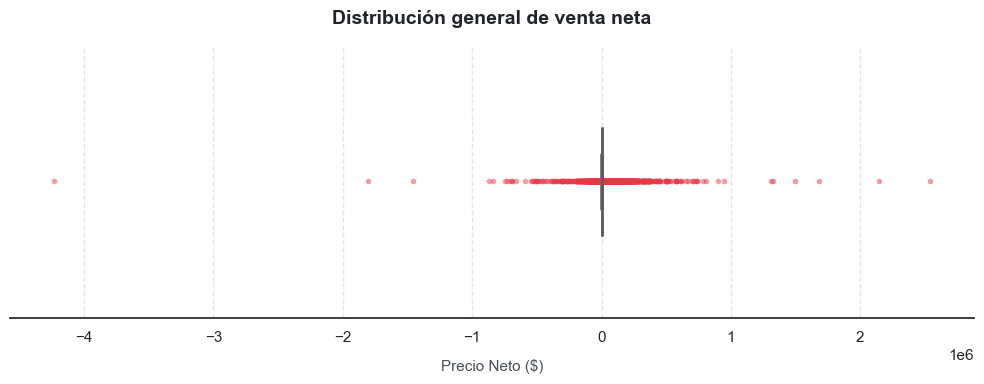

In [9]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 4), dpi=100)

sns.boxplot(
    x=sales_prep['net_price'],
    color='#4361ee',
    width=0.4,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

plt.title('Distribución general de venta neta', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine(left=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

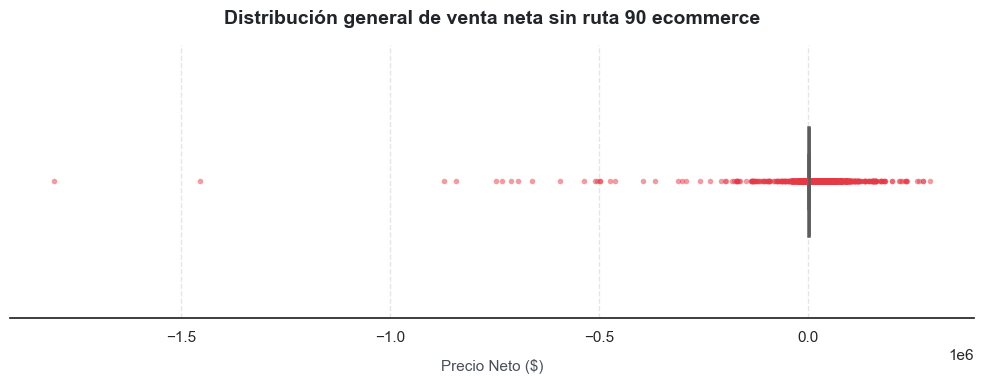

In [10]:
#eliminamos la ruta 90
sales_wn_90 = sales_prep[sales_prep['route_id'] != '90']

sns.set_theme(style="white")
plt.figure(figsize=(10, 4), dpi=100)

sns.boxplot(
    x=sales_wn_90['net_price'],
    color='#4361ee',
    width=0.4,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

plt.title('Distribución general de venta neta sin ruta 90 ecommerce', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine(left=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

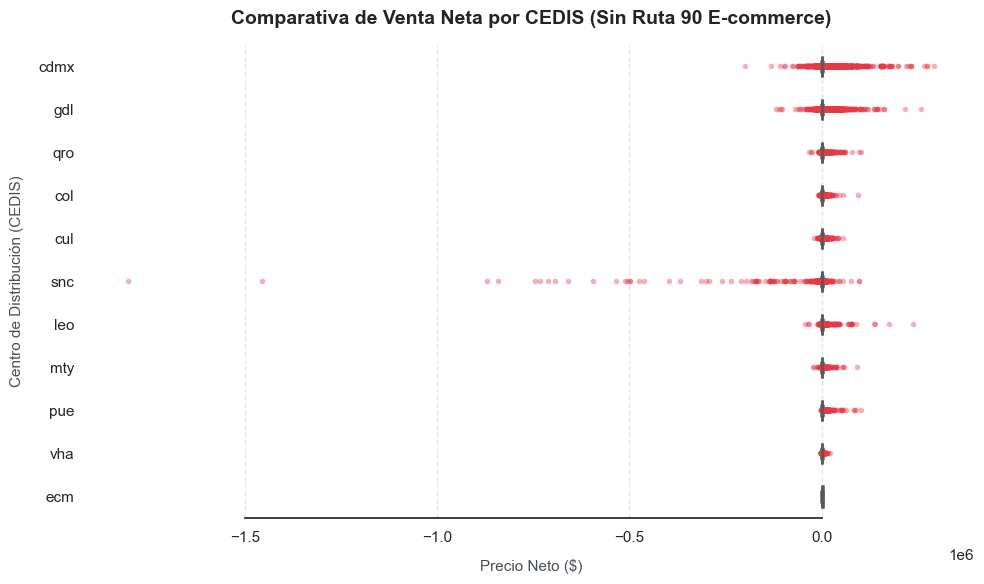

In [11]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6), dpi=100)

sns.boxplot(
    data=sales_wn_90,
    x='net_price',
    y='warehouse_id',
    hue='warehouse_id',
    palette='Set2',
    width=0.5,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.4
    }
)

plt.title('Comparativa de Venta Neta por CEDIS (Sin Ruta 90 E-commerce)', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Centro de Distribución (CEDIS)', fontsize=11, labelpad=10, color='#495057')


sns.despine(left=True, trim=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Criterio estadístico contra la naturaleza del negocio

Matemáticamente, la librería `seaborn.boxplot` no evalúa los datos con base en el promedio, sino que utiliza el Rango Intercuartílico para delimitar los umbrales de normalidad. La caja abarca el $50\%$ central de las transacciones (del cuartil $Q1$ al $Q3$). Los límites máximos permisibles se calculan mediante las siguientes ecuaciones:

$$\text{Límite Superior} = Q3 + 1.5 \times \text{IQR}$$

$$\text{Límite Inferior} = Q1 - 1.5 \times \text{IQR}$$

Cualquier registro que exceda estos límites es botado gráficamente como un punto rojo (*outlier*).

En el contexto de la empresa, la inmensa mayoría de los tickets generados en las rutas comerciales corresponden a compras cotidianas de bajo volumen, lo que provoca que la caja se comprima cerca del origen ($0$). Cuando ocurren eventos comerciales de alto impacto, la escala matemática se rompe:

* Picos positivos.

    Distribuidores pesados que realizan pedidos especiales por montos de cientos de miles o millones de pesos de forma esporádica.

* Picos negativos. 

    Generación de notas de crédito masivas y devoluciones de mercancía que impactan directamente el indicador de precio neto de venta.

#### Operación por CEDIS

El análisis gráfico permite segmentar el comportamiento del mercado en tres perfiles operativos claros:

* *CEDIS `snc`.*

    Presenta una dispersión atípica masiva en el espectro negativo, registrando movimientos de hasta $-\$1.5$ millones de pesos. Este comportamiento dicta la existencia de devoluciones consolidadas o notas de crédito de gran escala aplicadas a cuentas corporativas.
    
    Sin embargo, es totalmente normal considerando que snc significa `Sin clasificar`, ya que se usa para cuentas, rutas o clientes que ya no existen y que necesitan registrar movimientos o ajustes contables.

    A su vez, no es viable eliminarla, debido a que se sigue usando día con día y es parte del comportamiento logpistico y comercial de Urvet.


* *CEDIS `gdl` y `cdmx`.*

    Muestran las colas de puntos atípicos más largas en el espectro positivo. Son las regiones donde se concentran los clientes mayoristas con mayor poder de compra, rompiendo constantemente los techos de venta promedio de la ruta tradicional.

* *CEDIS `ecm`.*

    Muestra una distribución sin *outliers* significativos. Esto gracias a la remoción de la ruta 90.

### Transformaciones y agrupaciones

In [12]:
#set index para ordenar cronologicamente y usar resampling
sales_wn_90['sale_date'] = pd.to_datetime(sales_wn_90['sale_date'], errors='coerce')

#establecimiento de fecha de venta como index
sales_date_index= sales_wn_90.set_index('sale_date')

#reordenar para que resample llene los dias con huecos o venta 0
sales_date_index= sales_date_index.sort_index()

sales_date_index

,doc_id,total_cost,net_price,gross_price,profit,quantity,customer_id,product_id,product_class_id,route_id,warehouse_id
sale_date,,,,,,,,,,,
2024-01-02,ln 48569,203.03,408.41,408.42,205.39,5.00,50649,PUP1,dmd,57,leo
2024-01-02,gdl 407382,"2,526.10","4,768.00","4,768.00","2,241.90",50.00,11309,SP259,msd,41,gdl
2024-01-02,gdl 407382,0.00,0.00,0.00,-0.00,26.00,11309,JERNOBI,msd,41,gdl
2024-01-02,gdl 407382,454.13,982.20,982.20,528.07,20.00,11309,INTO15906,msd,41,gdl
2024-01-02,gdl 407416,162.39,316.55,316.55,154.16,1.00,12323,8+6,nat,75,gdl
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18,gdl 490062,207.99,437.59,437.59,229.60,1.00,12466,SBP6,nat,26,gdl
2026-05-18,gdl 490128,827.66,"1,633.66","1,633.66",806.00,1.00,50843,SBP40,nat,1,gdl
2026-05-18,mty 30479,632.83,"1,318.97","1,318.97",686.13,1.00,51459,SAL30,nat,78,mty


In [13]:
#agrupación diaria
sales_agg_daily = sales_date_index['net_price'].resample('D').sum()
sales_agg_daily

sale_date
2024-01-02     719,422.63
2024-01-03     992,292.59
2024-01-04     802,011.48
2024-01-05     484,853.02
2024-01-06      60,058.17
                 ...     
2026-05-14   1,635,507.52
2026-05-15     861,143.61
2026-05-16           0.00
2026-05-17       5,994.60
2026-05-18   1,239,253.54
Freq: D, Name: net_price, Length: 868, dtype: float64

In [14]:
sales_agg_daily.describe()

count          868.00
mean       870,441.66
std        788,178.92
min     -2,533,406.24
25%              0.00
50%        914,769.54
75%      1,354,204.81
max      4,633,339.51
Name: net_price, dtype: float64

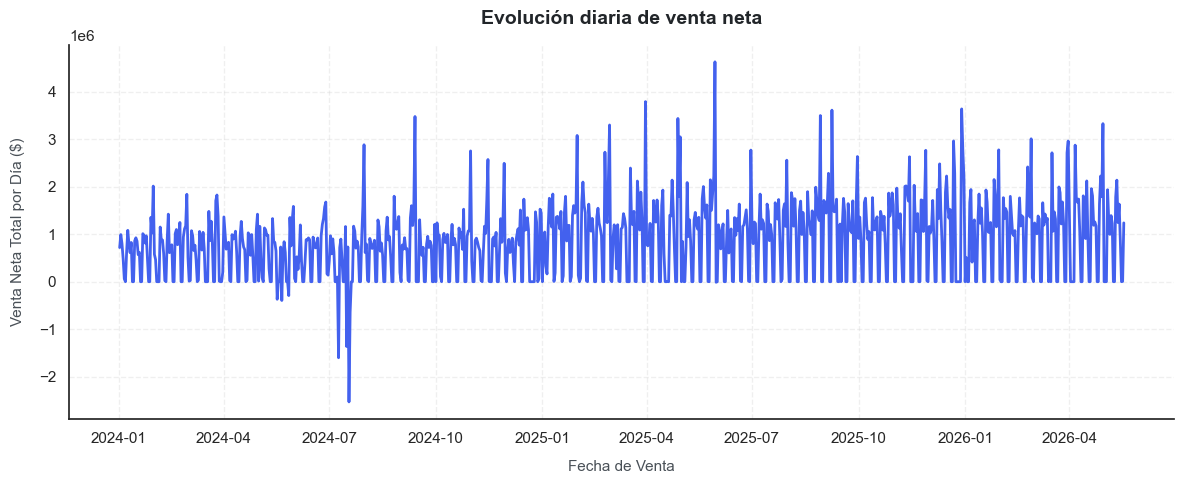

In [15]:
sns.set_theme(style="white")
plt.figure(figsize=(12, 5), dpi=100)

sns.lineplot(
    x=sales_agg_daily.index, 
    y=sales_agg_daily.values,
    color='#4361ee',
    linewidth=2
)


plt.title('Evolución diaria de venta neta', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Fecha de Venta', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Venta Neta Total por Día ($)', fontsize=11, labelpad=10, color='#495057')

# Estética limpia
sns.despine()
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

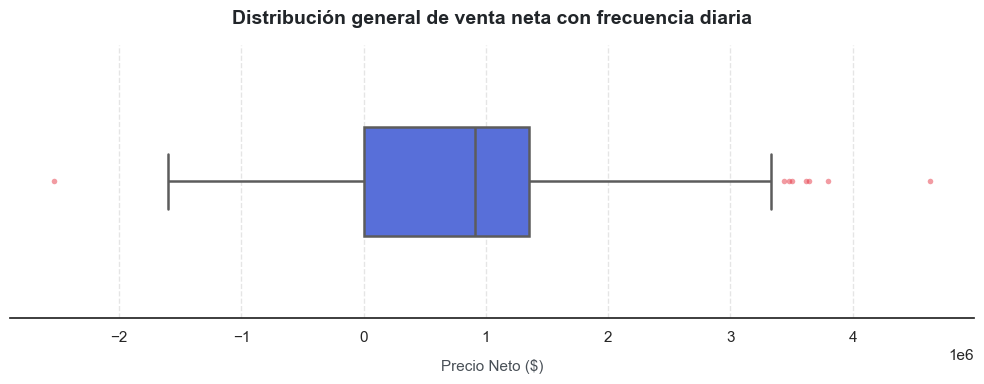

In [16]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 4), dpi=100)

sns.boxplot(
    x=sales_agg_daily.values,
    color='#4361ee',
    width=0.4,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

plt.title('Distribución general de venta neta con frecuencia diaria', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine(left=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Hallazgo de Anomalías Negativas Críticas

A nivel transaccional crudo, se habían detectado múltiples desviaciones severas. Al consolidar la serie por día, el impacto de estas anomalías disminuyó gracias a la compensación natural con los ingresos positivos de las rutas. Sin embargo, el gráfico de evolución diaria reveló un evento crítico:

* *Valores negativos de julio de 2024.*

    Durante este periodo, la serie registró una caída histórica vertical que arrastró el neto consolidado de toda la empresa hasta -$2.5 millones de pesos en una sola jornada.
    
    Al estar agrupado por día, este hallazgo confirma que no se trata de un error de registro aislado, sino de un impacto financiero masivo (como una devolución corporativa consolidada o la aplicación de notas de crédito de gran escala) que distorsiona por completo la varianza normal del negocio.

#### Identificación Visual de Estacionalidad Semanal

La gráfica de línea expuso un comportamiento cíclico altamente repetitivo con una morfología típica de dientes de sierra:

* *Ciclos de operación rígidos.*

    Se observan caídas sistemáticas que descienden casi a cero de forma idéntica cada siete días (correspondientes a los días de descanso o nula distribución en campo), seguidas de picos de surtido a mitad de semana.

* *Alineación de parámetros predictivos.*

    Aunque este comportamiento aún no está demostrado estadísticamente mediante funciones de autocorrelación (ACF/PACF) o pruebas formales de raíces unitarias, esta hipótesis visual robusta proporciona una guía clara para la calibración de hiperparámetros.
    
    En el caso del modelo SARIMAX, esto sugiere configurar el parámetro estacional en $s = 7$ (frecuencia diaria con ciclo semanal).

#### Imputación para valores atípicos

Dejar las caidas de julio de 2024 intacto sesgaría los pronósticos futuros hacia abajo, mientras que borrar la fila destruiría la continuidad del calendario, provocando que los modelos matemáticos fallen por falta de frecuencia histórica (`Freq: D`). Para solucionar esto, el pipeline implementará un protocolo de Interpolación Lineal:

* *Mecanismo técnico.*

    El día de la anomalía severa será aislado y su valor se reemplazará temporalmente con un valor nulo (`np.nan`). Posteriormente, se ejecutará el método `.interpolate(method='linear')` de Pandas.

* *Justificación matemática.*

    Este algoritmo calculará la pendiente geométrica entre el día anterior y el día posterior al desastre financiero, uniendo ambos puntos con una línea recta.
    
    Esto suaviza el cráter de forma local, preserva la tendencia del momento, mantiene intacta la estructura de la serie temporal y evita que los algoritmos de Machine Learning (como las redes neuronales LSTM) calculen mal la volatilidad operativa.

In [17]:
#verificación de valores atípicos

#uso del método de boxplot, ahora que sabemos que los valores atípicos son mínimos, 
# podemos removerlos sin miedo a alterar exceisvamente los datos
Q1 = sales_agg_daily.quantile(0.25)
Q3 = sales_agg_daily.quantile(0.75)
IQR = Q3 - Q1
lowest_lim = Q1 - 1.5 * IQR
higher_lim = Q3 + 1.5 * IQR

#todo lo que esté fuera de los límites, es considerado outliers
lowest_outs = sales_agg_daily[sales_agg_daily < lowest_lim]
higher_outs = sales_agg_daily[sales_agg_daily > higher_lim]


print(f"Umbral")
print(f"Monto diario normal va de ${lowest_lim:,.2f} hasta ${higher_lim:,.2f}\n")

print(f"\nOutliers negativos -> Total: {len(lowest_outs)}")

if not lowest_outs.empty:
    print(lowest_outs.map(lambda x: f"${x:,.2f}"))
else:
    print("No hay outliers negativos.")

print(f"\nOutliers positivos -> Total: {len(higher_outs)}")
if not higher_outs.empty:
    print(higher_outs.map(lambda x: f"${x:,.2f}"))
else:
    print("No hay outliers positivos.")

Umbral
Monto diario normal va de $-2,031,307.22 hasta $3,385,512.04


Outliers negativos -> Total: 1
sale_date
2024-07-18    $-2,533,406.24
Freq: D, Name: net_price, dtype: str

Outliers positivos -> Total: 7
sale_date
2024-09-13    $3,480,797.35
2025-03-31    $3,794,950.64
2025-04-28    $3,439,743.69
2025-05-30    $4,633,339.51
2025-08-29    $3,501,584.79
2025-09-08    $3,615,437.55
2025-12-29    $3,641,396.23
Name: net_price, dtype: str


#### Outlier negativo

La auditoría identificó estrictamente 1 registro que rompió el límite inferior de control:

* *`2024-07-18` ($-\$2,533,406.24$).*

    Este punto representa una caída vertical atípica y aislada en la historia de la compañía. Al analizar el entorno, se determina que no responde a un patrón de contracción del mercado, sino a un evento administrativo masivo y extraordinario (como una devolución corporativa consolidada en un solo folio). Al ser un evento único y no sistemático, destruye la capacidad del modelo para aprender la varianza real del negocio.

#### Outlier positivo

Hacia el espectro positivo, el algoritmo detectó 7 registros que superaron de forma masiva el límite de los $3.39 millones de pesos diarios:

* *`2024-09-13` ($3,480,797.35)*
* *`2025-03-31` ($3,794,950.64) $\rightarrow$ Cierre de Trimestre (Q1)*
* *`2025-04-28` ($3,439,743.69)*
* *`2025-05-30` ($4,633,339.51) $\rightarrow$ Cierre de Mes / Máximo Histórico*
* *`2025-08-29` ($3,501,584.79) $\rightarrow$ Cierre de Mes*
* *`2025-09-08` ($3,615,437.55)*
* *`2025-12-29` ($3,641,396.23) $\rightarrow$ Cierre de Año / Cierre Q4*

A diferencia de la anomalía negativa, los picos positivos revelan un patrón comercial sistemático: El Efecto Cierre de Mes. Las fechas demuestran que la fuerza de ventas de Urvet y los distribuidores mayoristas concentran las compras de gran volumen en las jornadas finales de cada periodo para alcanzar metas, bonos de volumen o cuotas trimestrales de distribución.

* *Tratamiento del Outlier Negativo: Imputación por Interpolación Lineal.*

    El registro del 2024-07-18 será anulado reemplazando su valor por un nulo (`np.nan`). Inmediatamente después, se aplicará una interpolación lineal geométrica tomando como referencia los días adyacentes de esa misma semana. Esto suaviza la caída financiera en la serie de tiempo, permitiendo que la red LSTM calcule correctamente la matriz de pesos sin deformar la frecuencia diaria continua (`Freq: D`).

    Este procedimiento será aplicado mas adelaante para valores que después del tratamiento del primer outlier, sigan siendo poco comunes o de ajustes contables evidentes.

* *Tratamiento de los Outliers Positivos: Conservación e Ingeniería de Características.*

    Está estrictamente prohibido eliminar o suavizar los 7 picos altos, ya que representan facturación y demanda real de inventario de los centros de distribución. Para que los modelos capturen estos saltos dinámicos de fin de mes, se implementarán variables exógenas de control en el modelo *SARIMAX* (columnas de intervención temporales y banderas de tipo indicador para días de cierre de mes), permitiendo al algoritmo anticipar y replicar estos picos de facturación en las proyecciones futuras.

In [18]:
#tratamiento de valor atípico negativo
date_to_input = '2024-07-18'

sales_agg_daily_clean = sales_agg_daily.copy()

if date_to_input in sales_agg_daily_clean.index:
    sales_agg_daily_clean.loc[date_to_input] = np.nan

    sales_agg_daily_clean = sales_agg_daily_clean.interpolate(method='linear')

    print(f'inputación en {date_to_input} ejecutada')

inputación en 2024-07-18 ejecutada


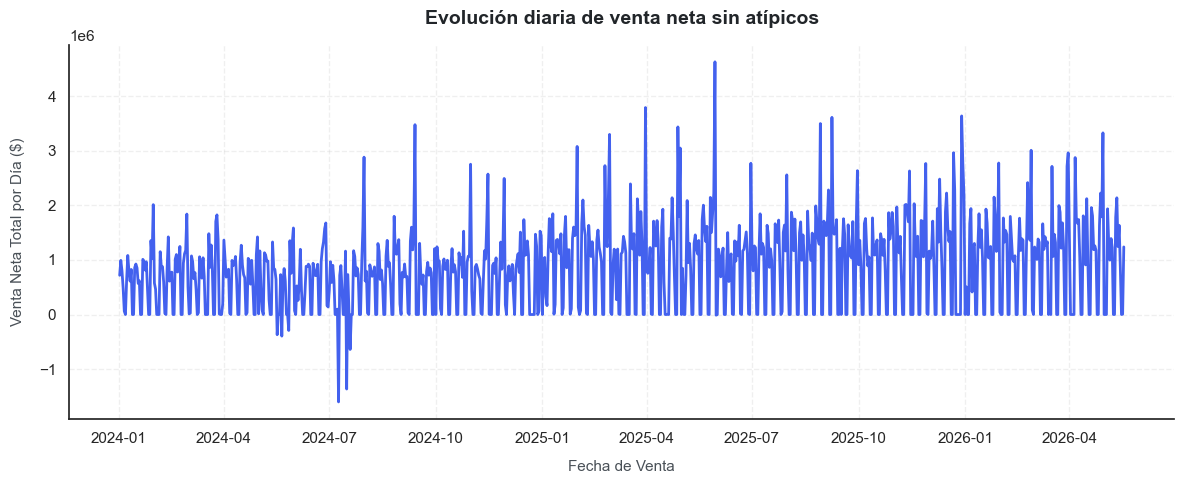

In [19]:
sns.set_theme(style="white")
plt.figure(figsize=(12, 5), dpi=100)

sns.lineplot(
    x=sales_agg_daily_clean.index, 
    y=sales_agg_daily_clean.values,
    color='#4361ee',
    linewidth=2
)


plt.title('Evolución diaria de venta neta sin atípicos', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Fecha de Venta', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Venta Neta Total por Día ($)', fontsize=11, labelpad=10, color='#495057')

# Estética limpia
sns.despine()
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

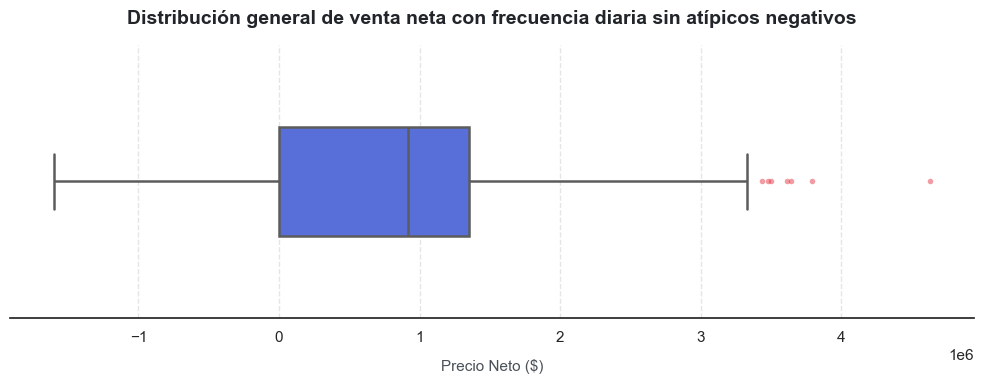

In [20]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 4), dpi=100)

sns.boxplot(
    x=sales_agg_daily_clean.values,
    color='#4361ee',
    width=0.4,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

plt.title('Distribución general de venta neta con frecuencia diaria sin atípicos negativos', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine(left=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
#validacion de mas outliers negativos
sales_agg_daily_clean = sales_agg_daily.copy()


outs_days = sales_agg_daily_clean[sales_agg_daily_clean < 0].index


print(f"Días anómalos detectados por regla de negocio: {len(outs_days)}")
for fecha in outs_days:
    print(f"{fecha.strftime('%Y-%m-%d')}: ${sales_agg_daily_clean[fecha]:,.2f}")

sales_agg_daily_clean[sales_agg_daily_clean <= 0] = np.nan

sales_agg_daily_clean = sales_agg_daily_clean.interpolate(method='linear')

Días anómalos detectados por regla de negocio: 18
2024-05-17: $-370,386.91
2024-05-21: $-395,839.35
2024-05-27: $-292,195.43
2024-07-09: $-1,602,553.08
2024-07-16: $-1,366,120.85
2024-07-18: $-2,533,406.24
2024-07-19: $-640,612.68
2024-07-20: $-984.91
2025-05-31: $-12,022.34
2025-07-13: $-149.03
2025-08-31: $-708.80
2025-09-27: $-73.31
2026-01-24: $-97.20
2026-02-01: $-530.25
2026-02-07: $-45.62
2026-02-14: $-670.37
2026-02-15: $-1,556.45
2026-02-21: $-157.87


Dado que 18 datos representan menos del 2% de los datos, optamos por llenarlos directamente también con interpolación lineal.

In [22]:
# Un solo paso automatizado para limpiar el histórico diario
sales_agg_daily_final = sales_agg_daily.copy()

sales_agg_daily_final[sales_agg_daily_final < 0] = np.nan
sales_agg_daily_final = sales_agg_daily_final.interpolate(method='linear')

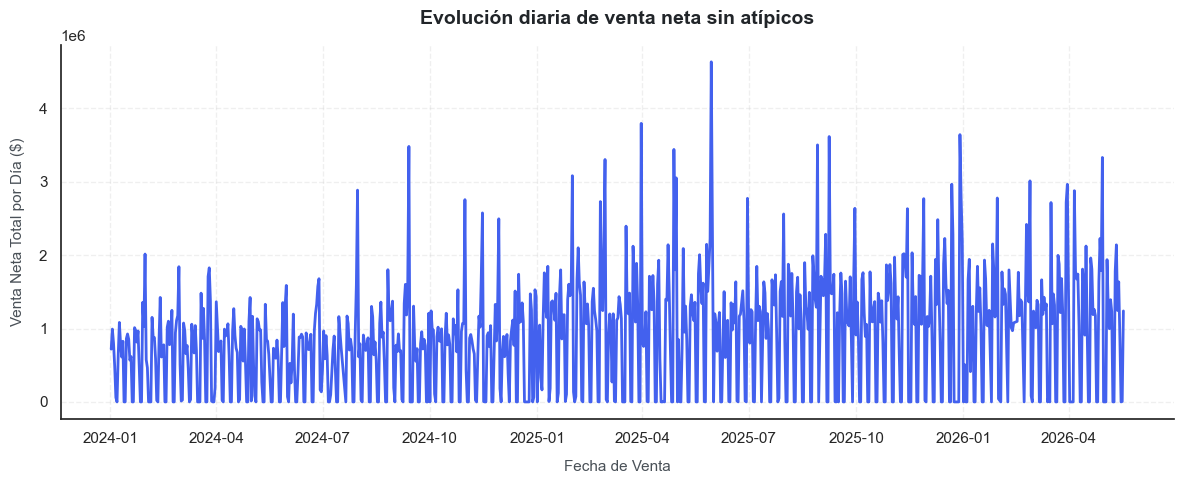

In [23]:
sns.set_theme(style="white")
plt.figure(figsize=(12, 5), dpi=100)

sns.lineplot(
    x=sales_agg_daily_final.index, 
    y=sales_agg_daily_final.values,
    color='#4361ee',
    linewidth=2
)


plt.title('Evolución diaria de venta neta sin atípicos', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Fecha de Venta', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Venta Neta Total por Día ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine()
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

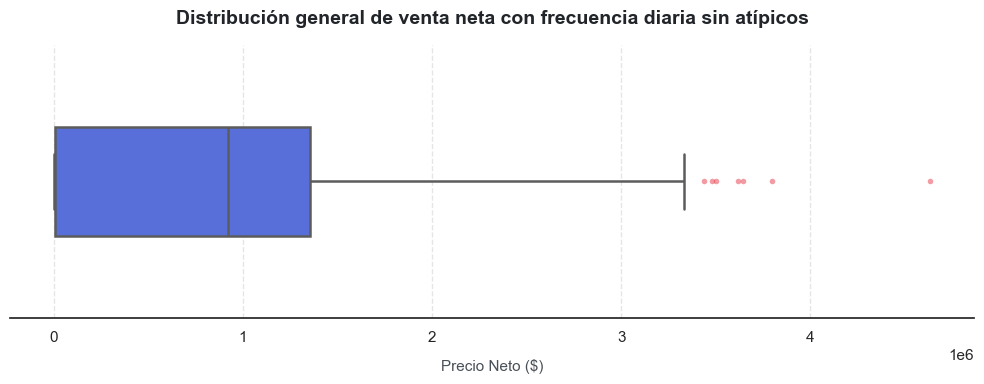

In [24]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 4), dpi=100)

sns.boxplot(
    x=sales_agg_daily_final.values,
    color='#4361ee',
    width=0.4,
    linewidth=1.8,
    fliersize=4,
    flierprops={
        'markerfacecolor': '#e63946',
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

plt.title('Distribución general de venta neta con frecuencia diaria sin atípicos', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Precio Neto ($)', fontsize=11, labelpad=10, color='#495057')

sns.despine(left=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Estacionalidad

Dada la visualización y la forma que sigue la serie, podemos plantearlo en forma de hipótesis

* H 0 -> no existe evidencia de estacionalidad semanal en la serie
* H 1 -> Existe evidencia de que hay estacionalidad semanal en la serie

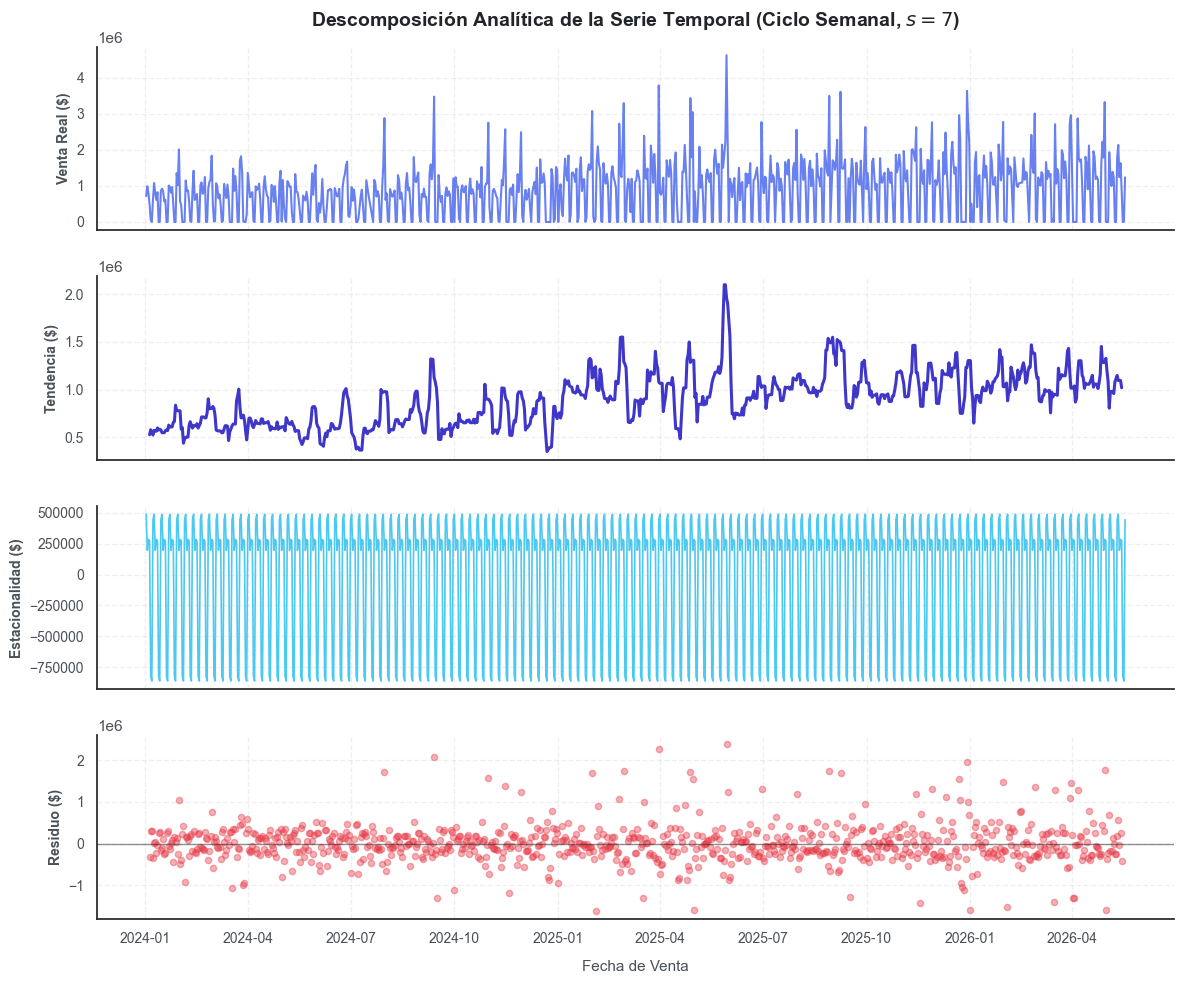

In [25]:
decompose = seasonal_decompose(sales_agg_daily_final, model='additive', period=7)

sns.set_theme(style="white")

observed = decompose.observed
trend = decompose.trend
seasonal = decompose.seasonal
resid = decompose.resid

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, dpi=100)


axes[0].plot(observed.index, observed.values, color='#4361ee', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Venta Real ($)', fontsize=10, fontweight='bold', color='#495057')
axes[0].set_title('Descomposición Analítica de la Serie Temporal (Ciclo Semanal, $s=7$)', 
                  fontsize=14, pad=15, fontweight='bold', color='#212529')

axes[1].plot(trend.index, trend.values, color='#3f37c9', linewidth=2.2)
axes[1].set_ylabel('Tendencia ($)', fontsize=10, fontweight='bold', color='#495057')

axes[2].plot(seasonal.index, seasonal.values, color='#4cc9f0', linewidth=1.2)
axes[2].set_ylabel('Estacionalidad ($)', fontsize=10, fontweight='bold', color='#495057')

axes[3].scatter(resid.index, resid.values, color='#e63946', alpha=0.4, s=20)
axes[3].axhline(0, color='#212529', linestyle='-', linewidth=1, alpha=0.5) # Línea base en cero
axes[3].set_ylabel('Residuo ($)', fontsize=10, fontweight='bold', color='#495057')
axes[3].set_xlabel('Fecha de Venta', fontsize=11, labelpad=10, color='#495057')

for ax in axes:
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    sns.despine(ax=ax, left=False, bottom=False)
    ax.tick_params(axis='both', labelsize=10, colors='#495057')


plt.tight_layout(h_pad=1.8)
plt.show()

La descomposición aditiva aplicada sobre la serie diaria de venta neta consolidada (con un periodo paramétrico de $s = 7$) permite aislar los componentes estructurales del comportamiento comercial de Urvet. Los hallazgos derivados de cada panel proporcionan la justificación matemática para la configuración del pipeline predictivo.

#### Componente Estacional

* Diagnóstico.

    Se rechaza la hipótesis nula ($H_0$) en favor de la hipótesis alternativa ($H_1$). Existe evidencia visual contundente de un patrón estacional de 7 días plenamente determinado y regular a lo largo de todo el histórico.

* Morfología del Ciclo Semanal.

    El componente estacional modela con precisión los ciclos operativos de la empresa.
    
    Identifica un valle estacional regular de -\$750,000 pesos respecto a la línea 
    base durante los días de nula actividad logística (domingos), el cual es compensado 
    de forma simétrica por crestas positivas de +\$250,000 pesos durante los días 
    pico de distribución en la semana. Este comportamiento cíclico regular permitirá 
    al modelo ajustar los pronósticos automáticos según el día del calendario.

* Impacto.

    Este hallazgo bloquea de forma definitiva el hiperparámetro estacional del modelo SARIMAX en una frecuencia de $s = 7$.

#### Componente del residuo

* Diagnóstico.

    El residuo representa la varianza que ni la tendencia de largo plazo ni el ciclo semanal de 7 días pudieron explicar. Si la serie fuera puramente matemática y lineal, este pánel mostraría ruido blanco homogéneo.

* Análisis de Negocio.

    En lugar de ruido blanco, el pánel de residuos exhibe ráfagas de picos positivos masivos que superan el millón de pesos de forma intermitente. Estos puntos coinciden con precisión con las fechas de cierre de mes y trimestre auditadas previamente mediante el criterio del $IQR$. Al remover el efecto del día de la semana, la gráfica demuestra que el esfuerzo comercial de fin de mes altera la varianza normal de la empresa de forma independiente.

* Impacto.

    Un modelo ARIMA clásico fallará al intentar predecir estos picos porque los residuos no son aleatorios. Esto justifica de manera obligatoria el uso de un modelo SARIMAX, donde estas anomalías positivas se modelarán utilizando la matriz exógena ($X_{exog}$) mediante banderas de  cierre de mes, permitiendo al algoritmo absorber este volumen extraordinario sin corromper la varianza del residuo.

### Estacionariedad

Para garantizar que los algoritmos predictivos (*SARIMAX* / *LSTM* / *Prophet*) realicen estimaciones estables sin sesgarse al infinito, es obligatorio validar estadísticamente si las propiedades de la serie, su media y su varianza, se mantienen constantes a lo largo del tiempo.

Para demostrarlo formalmente, se ejecuta la prueba de Dickey-Fuller aumentada (ADF) bajo el siguiente planteamiento de hipótesis estadísticas:

* $H_0$ (Hipótesis Nula).

    La serie de tiempo posee una raíz unitaria (No es estacionaria). Existe una dependencia temporal y la media cambia de forma sostenida debido al crecimiento orgánico del negocio.

* $H_1$ (Hipótesis Alternativa).
    
    La serie de tiempo no posee una raíz unitaria (Es estacionaria). Los datos fluctúan de manera homogénea alrededor de una media y varianza constantes, haciéndola apta para el modelado matemático.

In [26]:
#ejecucion de la prueba
result = adfuller(sales_agg_daily_final)


print(f"ADF: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Valores críticos:")
for k, v in result[4].items():
    print(f"{k}: {v:.4f}")

if result[1] <= 0.05:
    print("\n>> p-value <= 0.05, se rechaza H 0, la serie es estacionaria")
else:
    print("\n>> p-value > 0.05: no se rechaza H0. La serie no es estacionaria")

ADF: -3.2561
p-value: 0.0170
Valores críticos:
1%: -3.4381
5%: -2.8650
10%: -2.5686

>> p-value <= 0.05, se rechaza H 0, la serie es estacionaria


### Feature Engineering

Desarrollo y enriquecimiento de las variables de estudio a partir de las reglas de negocio de Urvet. En esta sección se transforman los datos crudos para estructurar los componentes clave del modelo.

* *Matrices exógenas.*

    Creación de las banderas temporales para identificar los días feriados oficiales de la Ley Federal del Trabajo y los rangos críticos de cierre de mes.

In [98]:
def exo_matrix_mapping(serie_diaria):
    X_exog = pd.DataFrame(index=serie_diaria.index)
    
    non_work_days = [
        # 2024
        '2024-01-01', '2024-03-18', '2024-03-28', '2024-03-29', '2024-05-01', 
        '2024-09-16', '2024-11-02', '2024-11-18', '2024-12-24',
        # 2025
        '2025-01-01', '2025-03-17', '2025-04-17', '2025-04-18', '2025-05-01', 
        '2025-09-16', '2025-11-17', '2025-12-24',
        # 2026
        '2026-01-01', '2026-03-16', '2026-04-02', '2026-04-03', '2026-05-01', 
        '2026-09-16', '2026-11-16', '2026-12-24'
    ]
    X_exog['non_work_day'] = X_exog.index.strftime('%Y-%m-%d').isin(non_work_days).astype(int)
    
    is_weekend = X_exog.index.weekday.isin([5, 6])

    is_non_workable = X_exog['non_work_day'] == 1
    X_exog['is_workday'] = ~(is_weekend | is_non_workable)
    

    X_exog['is_month_end'] = 0
    X_exog['close_month_zone'] = 0
    

    for period, group in X_exog.groupby(X_exog.index.to_period('M')):
        work_days_month = group[group['is_workday']].index
        
        #cierre del mes, ultimo dia
        if len(work_days_month) >= 1:
            X_exog.loc[work_days_month[-1], 'is_month_end'] = 1
        
        #ultimos dos dias del mes sin considerar el ultimo día cierre
        if len(work_days_month) >= 3:
            X_exog.loc[work_days_month[-3:-1], 'close_month_zone'] = 1
        elif len(work_days_month) == 2:
            X_exog.loc[work_days_month[0], 'close_month_zone'] = 1

    X_exog = X_exog.drop(columns=['is_workday'])
    
    return X_exog

In [99]:
#concat de dfs
exo_matrix = exo_matrix_mapping(sales_agg_daily_final)
master = pd.concat([sales_agg_daily_final, exo_matrix], axis=1)

display(exo_matrix)

display(sales_agg_daily_final)

display(master)


,non_work_day,is_month_end,close_month_zone
sale_date,,,
2024-01-02,0,0,0
2024-01-03,0,0,0
2024-01-04,0,0,0
2024-01-05,0,0,0
2024-01-06,0,0,0
...,...,...,...
2026-05-11,0,0,0
2026-05-12,0,0,0
2026-05-13,0,0,1


sale_date
2024-01-02     719,422.63
2024-01-03     992,292.59
2024-01-04     802,011.48
2024-01-05     484,853.02
2024-01-06      60,058.17
                 ...     
2026-05-11   1,790,415.58
2026-05-12   2,139,962.69
2026-05-13   1,245,428.49
2026-05-14   1,656,746.25
2026-05-15     646,434.79
Freq: D, Name: net_price, Length: 865, dtype: float64

,net_price,non_work_day,is_month_end,close_month_zone
sale_date,,,,
2024-01-02,"719,422.63",0,0,0
2024-01-03,"992,292.59",0,0,0
2024-01-04,"802,011.48",0,0,0
2024-01-05,"484,853.02",0,0,0
2024-01-06,"60,058.17",0,0,0
...,...,...,...,...
2026-05-11,"1,790,415.58",0,0,0
2026-05-12,"2,139,962.69",0,0,0
2026-05-13,"1,245,428.49",0,0,1


In [100]:
#exportacion limpia para pruebas con diferentes modelos
master.to_csv(f"{DATA_DIR}/master.csv")